# Task (a) — Simulating tracks and detector hits in 2D

For the first task I wrote a small Monte-Carlo simulator for a simplified 2D
detector. The physics is deliberately simple. There is no magnetic field and
every particle starts at the origin, so each track is just a straight line out
from (0,0). A line through the origin only has one free parameter and its
direction. I describe a track by a single angle phi between 0 and 2*pi.
A point on that track is (r*cos phi, r*sin phi) for r >= 0.

The detector is five concentric circles with radii 2, 4, 6, 8, 10. Because
every track goes through the origin (the shared centre of all the circles), the
point where a track crosses a circle of radius R is simply (R*cos phi,
R*sin phi). I don't need to solve a line-circle intersection. Each track leaves
one hit per circle, so a 3-track event has 3 x 5 = 15 hits.

### Setup


In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- simulator ----
COLUMNS = ["event_id", "track_id", "layer", "x", "y", "phi"]


def detector_radii(n_circles: int = 5, spacing: float = 2.0) -> np.ndarray:
    return spacing * np.arange(1, n_circles + 1)


def sample_track_angles(n_tracks: int,
                        rng: np.random.Generator,
                        min_sep: float = 0.0) -> np.ndarray:
    if min_sep <= 0.0:
        return rng.uniform(0.0, 2.0 * np.pi, size=n_tracks)

    phis: list[float] = []
    while len(phis) < n_tracks:
        cand = rng.uniform(0.0, 2.0 * np.pi)
        if all(_angular_gap(cand, p) >= min_sep for p in phis):
            phis.append(cand)
    return np.array(phis)


def _angular_gap(a: float, b: float) -> float:
    d = abs(a - b) % (2.0 * np.pi)
    return min(d, 2.0 * np.pi - d)


def track_hits(phi: float, radii: np.ndarray) -> np.ndarray:
    # Ideal hits of one track on each circle: just (R*cos phi, R*sin phi).
    x = radii * np.cos(phi)
    y = radii * np.sin(phi)
    return np.column_stack([x, y])


def simulate_event(event_id: int,
                   n_tracks: int = 3,
                   n_circles: int = 5,
                   spacing: float = 2.0,
                   efficiency: float = 1.0,
                   smear: float = 0.0,
                   min_sep: float = 0.0,
                   rng: np.random.Generator | None = None) -> pd.DataFrame:
    if rng is None:
        rng = np.random.default_rng()

    radii = detector_radii(n_circles, spacing)
    phis = sample_track_angles(n_tracks, rng, min_sep=min_sep)

    rows = []
    for track_id, phi in enumerate(phis):
        hits = track_hits(phi, radii)                 
        keep = rng.random(n_circles) < efficiency
        layers = np.nonzero(keep)[0]
        hits = hits[keep]
        if smear > 0.0 and len(hits):
            sigma = smear * radii[keep]
            noise = rng.normal(0.0, 1.0, hits.shape) * sigma[:, None]
            hits = hits + noise

        for layer, (x, y) in zip(layers, hits):
            rows.append((event_id, track_id, layer, x, y, phi))

    return pd.DataFrame(rows, columns=COLUMNS)


def simulate_events(n_events: int, seed: int | None = None, **kwargs) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    frames = [simulate_event(i, rng=rng, **kwargs) for i in range(n_events)]
    return pd.concat(frames, ignore_index=True)


# ---- plotting ----
_COLORS = plt.cm.tab10.colors
def draw_detector(ax, radii):
    for r in radii:
        ax.add_patch(plt.Circle((0, 0), r, fill=False, color="tab:blue", lw=1.1))


def plot_event(event, ax=None, radii=None, show_rays=True, legend=True):
    if radii is None:
        radii = detector_radii(5, 2.0)
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))

    R = radii.max()
    draw_detector(ax, radii)

    for track_id, g in event.groupby("track_id"):
        c = _COLORS[track_id % 10]
        if show_rays:
            phi = g["phi"].iloc[0]
            ax.plot([0, R * np.cos(phi)], [0, R * np.sin(phi)],
                    color=c, lw=1, alpha=0.5)
        ax.scatter(g["x"], g["y"], color=c, s=35, zorder=3,
                   label=f"track {track_id}")

    lim = R * 1.1
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_aspect("equal")
    ax.set_xlabel("x"); ax.set_ylabel("y")
    if legend:
        ax.legend(loc="upper right", fontsize=8)
    return ax

RADII = detector_radii(5, 2.0)
RADII

array([ 2.,  4.,  6.,  8., 10.])

## 1. One event — the hit table
Each row is one hit. The `track_id` column is the ground-truth label.

In [2]:
event = simulate_event(0, n_tracks=3, rng=np.random.default_rng(0))
event

,event_id,track_id,layer,x,y,phi
0,0,0,0,-1.304033,-1.516410,4.002148
1,0,0,1,-2.608065,-3.032820,4.002148
2,0,0,2,-3.912098,-4.549230,4.002148
3,0,0,3,-5.216130,-6.065640,4.002148
4,0,0,4,-6.520163,-7.582050,4.002148
5,0,1,0,-0.248007,1.984564,1.695120
6,0,1,1,-0.496014,3.969127,1.695120
7,0,1,2,-0.744021,5.953691,1.695120
8,0,1,3,-0.992029,7.938254,1.695120
9,0,1,4,-1.240036,9.922818,1.695120


## 2. Correctness check
Quick sanity check: since there's no smearing yet, every hit should sit exactly
on its circle. I check the distance from the origin against the nominal radius.

In [3]:
r = np.hypot(event["x"], event["y"])
expected = RADII[event["layer"].to_numpy()]
assert np.allclose(r, expected)
print("max deviation:", np.abs(r - expected).max())

max deviation: 0.0


## 3. Visualise one event

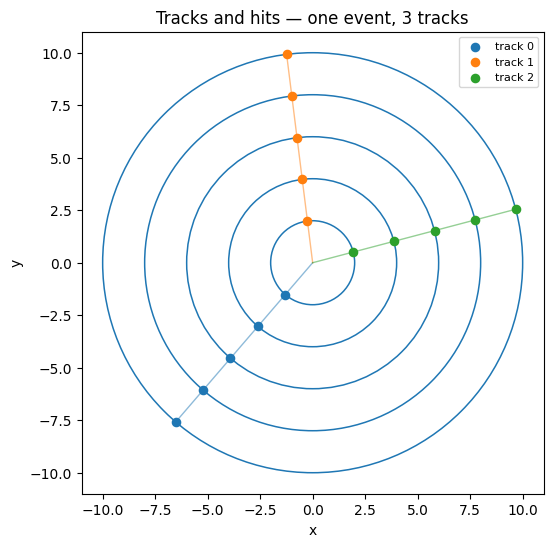

In [4]:
fig, ax = plt.subplots(figsize=(6, 6))
plot_event(event, ax=ax, radii=RADII)
ax.set_title("Tracks and hits — one event, 3 tracks")
plt.show()

## 4. Four independent events
Same rules, different random seeds. This is the Monte-Carlo idea where each event is
an independent random draw.

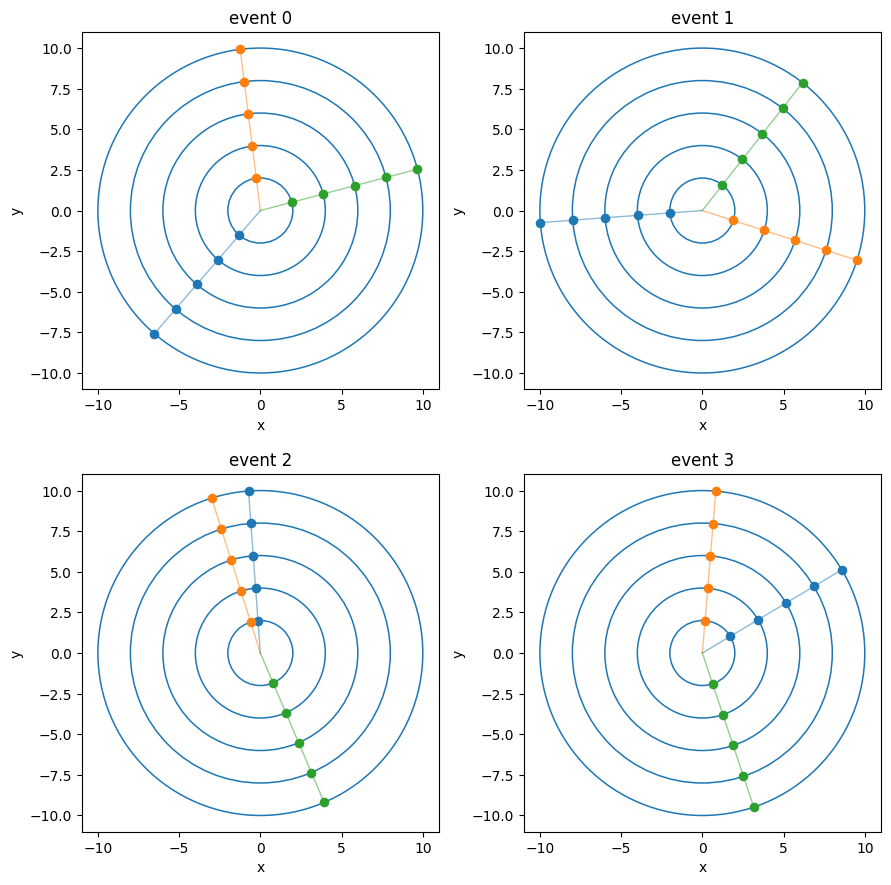

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(9, 9))
for i, ax in enumerate(axes.ravel()):
    ev = simulate_event(i, n_tracks=3, rng=np.random.default_rng(i))
    plot_event(ev, ax=ax, radii=RADII, legend=False)
    ax.set_title(f"event {i}")
fig.tight_layout(); plt.show()

## 5. Verification across many tracks
Plotting hit distance against layer for 200 events. Every point should land on
one of the five nominal radii, which confirms the geometry is right.

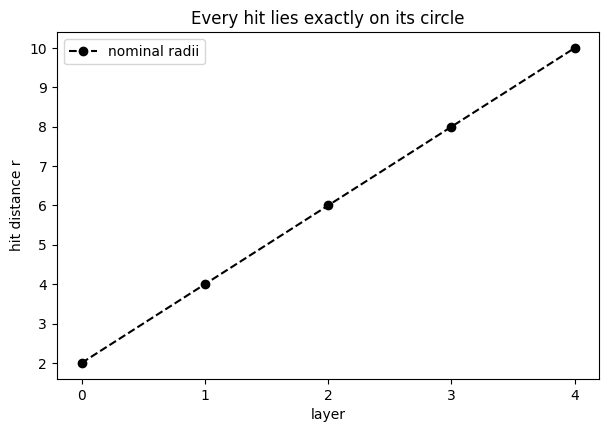

In [6]:
df = simulate_events(200, seed=1, n_tracks=3)
df["r"] = np.hypot(df["x"], df["y"])
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(df["layer"], df["r"], s=8, alpha=0.2, color="tab:purple")
ax.plot(range(5), RADII, "k--", marker="o", label="nominal radii")
ax.set_xlabel("layer"); ax.set_ylabel("hit distance r"); ax.set_xticks(range(5))
ax.set_title("Every hit lies exactly on its circle"); ax.legend(); plt.show()

## 6. The Monte-Carlo is unbiased
The track angles should come out uniform on [0, 2*pi) i.e. tracks are emitted
in all directions equally, with no preferred angle.

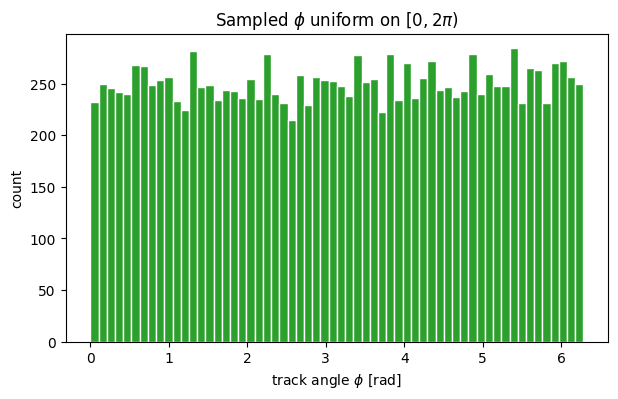

In [7]:
df_big = simulate_events(5000, seed=2, n_tracks=3)
phi_per_track = df_big.groupby(["event_id", "track_id"])["phi"].first()
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(phi_per_track, bins=60, color="tab:green", edgecolor="white")
ax.set_xlabel(r"track angle $\phi$ [rad]"); ax.set_ylabel("count")
ax.set_title(r"Sampled $\phi$ uniform on $[0, 2\pi)$"); plt.show()

## 7. All hits populate the rings
Overlaying every hit from many events because the angles are uniform, the hits
fill the detector circles evenly all the way around.

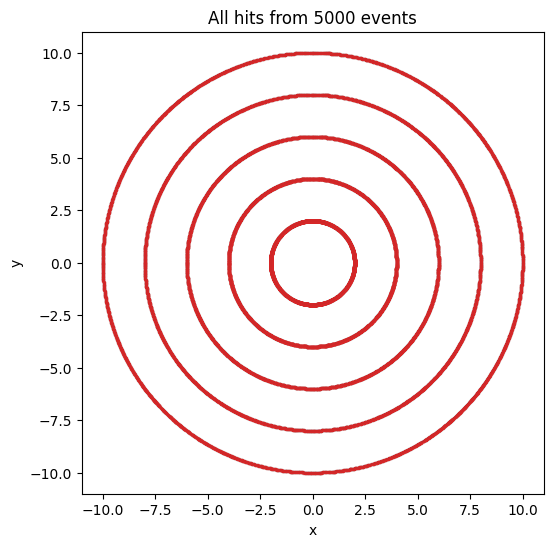

In [8]:
fig, ax = plt.subplots(figsize=(6, 6))
draw_detector(ax, RADII)
ax.scatter(df_big["x"], df_big["y"], s=2, alpha=0.15, color="tab:red")
lim = RADII.max()*1.1
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_aspect("equal")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title("All hits from 5000 events"); plt.show()

## Summary
To recap task (a): a track is one angle phi, and a hit is (R*cos phi, R*sin phi)
on each circle. The simulator outputs a tidy table with columns event_id,
track_id, layer, x, y, phi the same layout as the provided data. The track_id column is the supervised label
for the hit-to-track network.
